In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.datasets import mnist, fashion_mnist

I0000 00:00:1781656934.069156    9308 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781656934.966607    9308 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781656937.809884    9308 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
(x_train, t_train), (x_test, t_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print('\n train shape = ', x_train.shape)
print('\n, train label shape = ', t_train.shape)
print('\n test shape = ', x_test.shape)
print('\n, test label shape = ', t_test.shape)

print('\n train label = ', t_train)
print('\n test label = ', t_test)


 train shape =  (60000, 28, 28)

, train label shape =  (60000,)

 test shape =  (10000, 28, 28)

, test label shape =  (10000,)

 train label =  [9 0 0 ... 3 0 5]

 test label =  [9 2 1 ... 8 1 5]


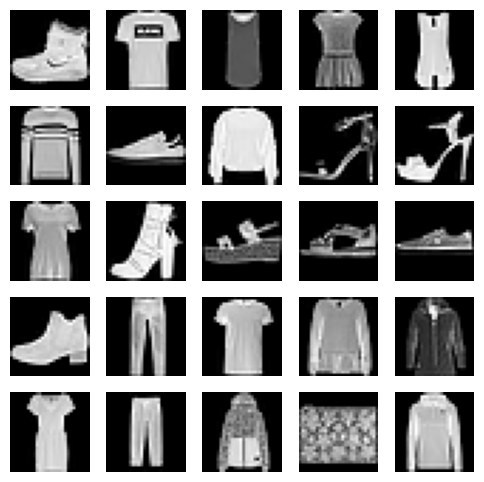

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
for index in range(25):
    plt.subplot(5,5, index + 1)
    plt.imshow(x_train[index], cmap='gray')
    plt.axis('off')

plt.show()

In [6]:
x_train = (x_train - 0.0 / (255.0 - 0.0))
# print(x_train)
x_test = (x_test - 0.0 / (255.0 - 0.0))

In [7]:
t_train = tf.keras.utils.to_categorical(t_train, num_classes=10)
t_test = tf.keras.utils.to_categorical(t_test, num_classes=10)

In [8]:
model =Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )
model.summary()

/home/work/git/TensorflowPjt/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1781588237.782566  212382 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

노두수 2/3(입력수 + 출력수)

In [9]:
hist = model.fit(x_train, t_train, epochs=30, validation_split=0.3)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6684 - loss: 4.4995 - val_accuracy: 0.6975 - val_loss: 0.9058
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6953 - loss: 0.8009 - val_accuracy: 0.7111 - val_loss: 0.7880
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7206 - loss: 0.6927 - val_accuracy: 0.7099 - val_loss: 0.7757
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7557 - loss: 0.6486 - val_accuracy: 0.7671 - val_loss: 0.6609
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7959 - loss: 0.5739 - val_accuracy: 0.7941 - val_loss: 0.6021
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8072 - loss: 0.5489 - val_accuracy: 0.8156 - val_loss: 0.5206
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8145 - loss: 0.5224 - val_accuracy: 0.8151 - val_loss: 0.5565
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8236 - loss: 0.5074 - 

In [10]:
model.evaluate(x_test,t_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8120 - loss: 0.6389


[0.6388953328132629, 0.8119999766349792]

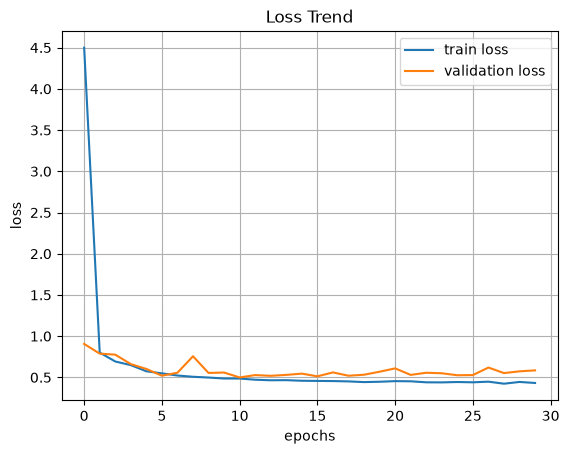

In [11]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='validation loss')
plt.legend(loc='best')
plt.show()

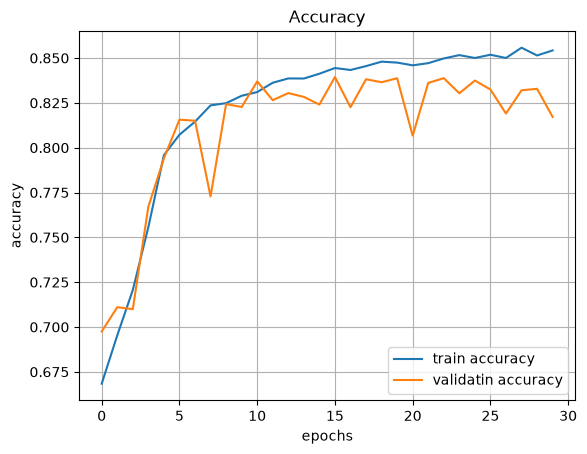

In [12]:
import matplotlib.pyplot as plt

plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()
plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='validatin accuracy')
plt.legend(loc='best')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


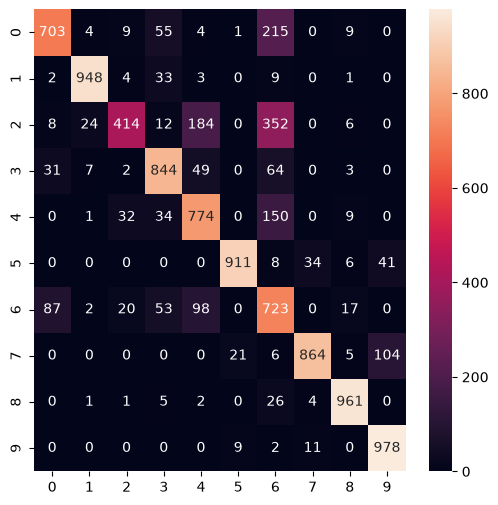

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
plt.figure(figsize=(6,6))
predicted_value = model.predict(x_test)

cm = confusion_matrix(np.argmax(t_test, axis=-1),
                      np.argmax(predicted_value, axis=-1))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()